# Validação do parser FTL

Este notebook valida materiais, seções, cotas, nós derivados, barras, apoios e cargas dos três arquivos de ponte. A implementação segue a topologia implícita do FTool: os nós são derivados dos endpoints das barras `2 1` e `4 1`. Todas as grandezas são normalizadas para SI (`N`, `m`, `Pa`).

In [1]:
import json
from math import isclose
from pathlib import Path

from src.converter_anastruct import to_anastruct
from src.exporter import axial_analysis_to_dict
from src.parser import FtlParser
from src.stick_sizing import (
    StickGeometry,
    StickSizingConfig,
    check_compression_section,
    check_tension_section,
    required_layers_for_tension,
    size_axial_members,
)
from src.visualizer import (
    plot_anastruct_result,
    plot_axial_forces,
    plot_ftool_model,
    plot_stick_sizing,
)

INPUT_DIR = Path("inputs")
files = sorted(INPUT_DIR.glob("ponte_*.ftl"))
assert len(files) == 3, f"Esperava 3 arquivos, encontrei {len(files)}"

parsers = {path.name: FtlParser(path) for path in files}
models = {name: parser.parse() for name, parser in parsers.items()}
list(models)

['ponte_1.ftl', 'ponte_2.ftl', 'ponte_3.ftl']

## Testes de regressão

As contagens abaixo são snapshots dos arquivos atuais. As demais verificações testam invariantes estruturais e impedem a regressão para o comportamento anterior, que não criava barras nem associava cargas.

In [2]:
expected_models = {
    "ponte_1.ftl": {
        "dimensions": 7, "nodes": 7, "members": 11,
        "pinned": (3.0, 2.25), "roller": (4.0, 2.25),
        "loaded": (3.5, 2.25), "load_fy": -367.88,
    },
    "ponte_2.ftl": {
        "dimensions": 7, "nodes": 8, "members": 13,
        "pinned": (3.0, 2.25), "roller": (4.0, 2.25),
        "loaded": (3.5, 2.25), "load_fy": -367.88,
    },
    "ponte_3.ftl": {
        "dimensions": 0, "nodes": 10, "members": 19,
        "pinned": (-0.525, 0.0), "roller": (0.525, 0.0),
        "loaded": (0.0, 0.0), "load_fy": -2_000.0,
    },
}

for name, model in models.items():
    expected = expected_models[name]

    assert len(model.materials) == 1
    assert len(model.sections) == 2
    assert len(model.point_loads) == 1
    assert len(model.dimensions) == expected["dimensions"]
    assert len(model.nodes) == expected["nodes"]
    assert len(model.members) == expected["members"]

    material = model.materials[0]
    assert material.name == "palito"
    assert isclose(material.elasticity, 7.35e9)
    assert isclose(material.weight, 10_000.0)

    assert [section.name for section in model.sections] == ["PALITO", "palito"]
    assert isclose(model.sections[0].area, 0.00784)
    assert isclose(model.sections[0].inertia, 0.0)
    assert isclose(model.sections[1].inertia, 0.00185)
    assert isclose(model.sections[0].width, 0.00784)
    assert isclose(model.sections[0].thickness, 0.0)
    assert isclose(model.sections[1].width, 0.00784)
    assert isclose(model.sections[1].thickness, 0.00185)

    node_ids = {node.id for node in model.nodes}
    assert all(member.length > 0 for member in model.members)
    assert all(member.start_node_id in node_ids for member in model.members)
    assert all(member.end_node_id in node_ids for member in model.members)
    assert all(member.material_name == "palito" for member in model.members)
    assert all(member.section_name in {"PALITO", "palito"} for member in model.members)
    assert all(state in (0, 1, 2) for node in model.nodes for state in (node.support.ux, node.support.uy, node.support.rz))

    pinned = [node for node in model.nodes if node.support.is_pinned]
    rollers = [node for node in model.nodes if node.support.is_roller_x]
    loaded = [node for node in model.nodes if node.load is not None]
    assert len(pinned) == len(rollers) == len(loaded) == 1
    assert isclose(pinned[0].x, expected["pinned"][0]) and isclose(pinned[0].y, expected["pinned"][1])
    assert isclose(rollers[0].x, expected["roller"][0]) and isclose(rollers[0].y, expected["roller"][1])
    assert isclose(loaded[0].x, expected["loaded"][0]) and isclose(loaded[0].y, expected["loaded"][1])
    assert isclose(loaded[0].load.fx, 0.0)
    assert isclose(loaded[0].load.fy, expected["load_fy"])
    assert isclose(loaded[0].load.moment, 0.0)

# parse() precisa ser idempotente na mesma instância.
model_again = parsers["ponte_1.ftl"].parse()
assert len(model_again.nodes) == 7
assert len(model_again.members) == 11
assert len(model_again.dimensions) == 7

print("Todos os testes do parser passaram.")

Todos os testes do parser passaram.


## Conversão e solução com anaStruct

Cada ID do FTool deve ter um correspondente no anaStruct. As pontes dos fixtures possuem rótulas nas duas extremidades de todas as barras e, por isso, são modeladas como treliças. O equilíbrio vertical é verificado em N.

In [3]:
analyses = {}

for name, model in models.items():
    analysis = to_anastruct(model)
    assert len(analysis.node_ids) == len(model.nodes)
    assert len(analysis.member_ids) == len(model.members)
    assert all(element.type == "truss" for element in analysis.system.element_map.values())

    analysis.solve()
    support_results = [
        analysis.get_reaction_results(node.id)
        for node in model.nodes
        if not node.support.is_free
    ]
    reaction_fx = sum(float(result["Fx"]) for result in support_results)
    reaction_fy = sum(float(result["Fy"]) for result in support_results)
    applied_fx = sum(node.load.fx for node in model.nodes if node.load is not None)
    applied_fy = sum(node.load.fy for node in model.nodes if node.load is not None)
    assert isclose(reaction_fx + applied_fx, 0.0, abs_tol=1e-8)
    assert isclose(reaction_fy + applied_fy, 0.0, abs_tol=1e-8)
    analyses[name] = analysis

print("Conversão, solução e equilíbrio validados.")

Conversão, solução e equilíbrio validados.


## Exportação da análise axial

O exportador produz dados JSON compatíveis, com schema versionado, unidades, conectividade, reações e forças axiais em N.

In [4]:
axial_data = axial_analysis_to_dict(
    models["ponte_3.ftl"],
    analyses["ponte_3.ftl"],
    name="ponte_3",
)

assert axial_data["schema_version"] == 1
assert axial_data["units"]["force"] == "N"
assert len(axial_data["members"]) == 19
assert [member["id"] for member in axial_data["members"]] == [f"m{i}" for i in range(1, 20)]
assert isclose(sum(reaction["fy"] for reaction in axial_data["reactions"]), 2_000.0)

#print(json.dumps(axial_data["members"][:4], ensure_ascii=False, indent=2))
print(json.dumps(axial_data["members"][16], ensure_ascii=False, indent=2))

{
  "id": "m17",
  "ftool_id": 95,
  "anastruct_id": 17,
  "start_node": "n2",
  "end_node": "n10",
  "material": "palito",
  "section": "palito",
  "length": 0.3132491111755371,
  "angle": 0.4993467292730783,
  "axial_force": {
    "start": -1553.3838499225153,
    "end": -1553.3838499225153,
    "minimum": -1553.3838499225153,
    "maximum": -1553.3838499225153,
    "state": "compression"
  }
}


## Dimensionamento axial e quantidade de palitos

A busca testa quantidades inteiras crescentes. Na compressão, considera a instabilidade nos dois eixos; na tração paralela às fibras, compara a tensão em MPa com `f_t0m`. Os parâmetros padrão podem ser substituídos pelos dados dos ensaios.

In [5]:
expected_sizing = {
    "ponte_1.ftl": {
        "layers": 31,
        "sticks": 129,
        "tension_members": 6,
        "compression": [("m2", 6, 4, 24), ("m4", 11, 5, 55), ("m5", 6, 4, 24)],
    },
    "ponte_2.ftl": {
        "layers": 29,
        "sticks": 101,
        "tension_members": 6,
        "compression": [("m2", 6, 4, 24), ("m7", 6, 4, 24), ("m11", 4, 3, 12), ("m12", 4, 3, 12)],
    },
    "ponte_3.ftl": {
        "layers": 144,
        "sticks": 408,
        "tension_members": 10,
        "compression": [
            ("m2", 3, 2, 6), ("m3", 4, 2, 8), ("m4", 18, 3, 54),
            ("m5", 3, 2, 6), ("m6", 4, 2, 8), ("m9", 24, 3, 72),
            ("m11", 24, 3, 72), ("m16", 22, 3, 66), ("m17", 22, 3, 66),
        ],
    },
}

sizing_reports = {}
for name, model in models.items():
    report = size_axial_members(model, analyses[name])
    expected = expected_sizing[name]
    compressed = [
        (member.id, member.required_layers, member.sticks_per_layer, member.total_sticks)
        for member in report.members
        if member.governing_mode == "compression"
    ]
    assert compressed == expected["compression"]
    assert report.total_required_layers == expected["layers"]
    assert report.total_physical_sticks == expected["sticks"]
    assert report.tension_members == expected["tension_members"]
    assert all(member.total_sticks is not None for member in report.members)

    for member in report.members:
        assert isclose(member.section_width_mm, 7.84)
        assert isclose(member.section_thickness_mm, 1.85)
        assert member.total_sticks == member.required_layers * member.sticks_per_layer
        if member.check is not None:
            assert member.check.passes
            assert member.check.layer_count == member.required_layers
        if member.compression_check and member.required_layers > 1:
            member_config = StickSizingConfig(
                stick=StickGeometry(
                    width_mm=member.section_width_mm,
                    thickness_mm=member.section_thickness_mm,
                ),
                use_section_geometry=False,
            )
            previous = check_compression_section(
                member.compression_demand_n,
                member.member_length_m,
                member.required_layers - 1,
                member_config,
            )
            assert not previous.passes

    json.dumps(report.to_dict(), allow_nan=False)
    sizing_reports[name] = report
    print(name, report.total_required_layers, report.total_physical_sticks)

stick_counts = sizing_reports["ponte_3.ftl"].counts_to_dict()
assert stick_counts["total_required_layers"] == 144
assert stick_counts["total_physical_sticks"] == 408
assert {item["id"]: item["total_sticks"] for item in stick_counts["members"]}["m4"] == 54

# Verificação ensinada pelo orientador, toda em N, mm² e MPa.
tension_config = StickSizingConfig(
    stick=StickGeometry(width_mm=8.0, thickness_mm=1.86),
    use_section_geometry=False,
)
tension_check = check_tension_section(2_000.0, 3, tension_config)
assert isclose(tension_check.area_mm2, 3 * 8.0 * 1.86)
assert isclose(tension_check.stress_mpa, 2_000.0 / tension_check.area_mm2)
assert tension_check.stress_mpa < 66.0 and tension_check.passes
assert required_layers_for_tension(2_000.0, tension_config).layer_count == 3
print(json.dumps(stick_counts, ensure_ascii=False, indent=2))

ponte_1.ftl 31 129
ponte_2.ftl 29 101
ponte_3.ftl 144 408
{
  "schema": "ftool-parser-python.stick-counts",
  "schema_version": 3,
  "scope": "axial_force_members",
  "units": {
    "force": "N",
    "member_length": "m",
    "section_and_stick_length": "mm"
  },
  "total_required_sticks": 408,
  "total_physical_sticks": 408,
  "total_required_layers": 144,
  "sized_member_count": 19,
  "compression_member_count": 9,
  "tension_member_count": 10,
  "compressed_lamination_length_m": 34.87430131723227,
  "total_lamination_length_m": 39.386351252413604,
  "commercial_stick_length_mm": 115.0,
  "splice_overlap_mm": 0.0,
  "members": [
    {
      "id": "m1",
      "ftool_id": 79,
      "start_node": "n1",
      "end_node": "n2",
      "length": 0.15,
      "compression_demand": 0.0,
      "tension_demand": 256.15882334524576,
      "governing_mode": "tension",
      "required_layers": 1,
      "sticks_per_layer": 2,
      "total_sticks": 2,
      "required_sticks": 2,
      "section_width_

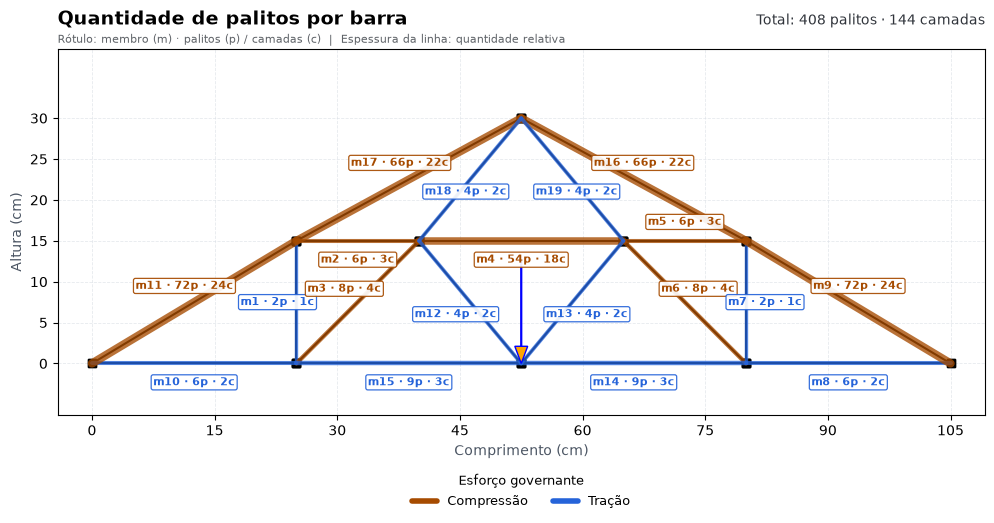

In [6]:
_ = plot_stick_sizing(
    models["ponte_3.ftl"],
    sizing_reports["ponte_3.ftl"],
    scale=0.6,
)

## Resumo dos modelos

In [7]:
for name, model in models.items():
    print(
        f"{name}: materiais={len(model.materials)}, seções={len(model.sections)}, "
        f"cargas={len(model.point_loads)}, cotas={len(model.dimensions)}, "
        f"nós={len(model.nodes)}, barras={len(model.members)}"
    )

ponte_1.ftl: materiais=1, seções=2, cargas=1, cotas=7, nós=7, barras=11
ponte_2.ftl: materiais=1, seções=2, cargas=1, cotas=7, nós=8, barras=13
ponte_3.ftl: materiais=1, seções=2, cargas=1, cotas=0, nós=10, barras=19


## Inspeção detalhada

O método `debug()` mostra conectividade, comprimentos, propriedades, apoios e a carga associada a cada nó.

In [8]:
parsers["ponte_3.ftl"].debug()

FTOOL 4.00: inputs\ponte_3.ftl
Materiais: 1
Seções: 2
Cargas nodais: 1
Cotas: 0
Nós derivados: 10
Barras físicas: 19

NÓS
  N1: (-0.275, 0) apoio=(0, 0, 0) carga=-
  N2: (-0.275, 0.15) apoio=(0, 0, 0) carga=-
  N3: (-0.125, 0.15) apoio=(0, 0, 0) carga=-
  N4: (0.125, 0.15) apoio=(0, 0, 0) carga=-
  N5: (0.275, 0.15) apoio=(0, 0, 0) carga=-
  N6: (0.275, 0) apoio=(0, 0, 0) carga=-
  N7: (0.525, 0) apoio=(0, 1, 0) carga=-
  N8: (-0.525, 0) apoio=(1, 1, 0) carga=-
  N9: (0, 0) apoio=(0, 0, 0) carga=força
  N10: (0, 0.3) apoio=(0, 0, 0) carga=-

BARRAS
  B79: N1 -> N2 L=0.15 material='palito' seção='palito'
  B80: N2 -> N3 L=0.15 material='palito' seção='palito'
  B81: N1 -> N3 L=0.212132 material='palito' seção='palito'
  B82: N3 -> N4 L=0.25 material='palito' seção='palito'
  B83: N4 -> N5 L=0.15 material='palito' seção='palito'
  B84: N4 -> N6 L=0.212132 material='palito' seção='palito'
  B85: N6 -> N5 L=0.15 material='palito' seção='palito'
  B86: N6 -> N7 L=0.25 material='palito' seçã

## Validação visual

ponte_1.ftl


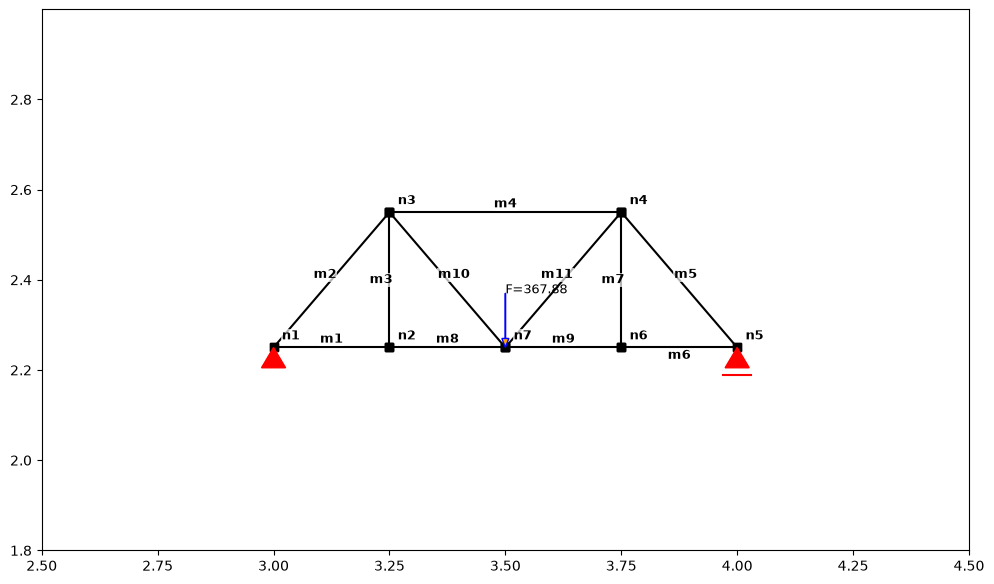

ponte_2.ftl


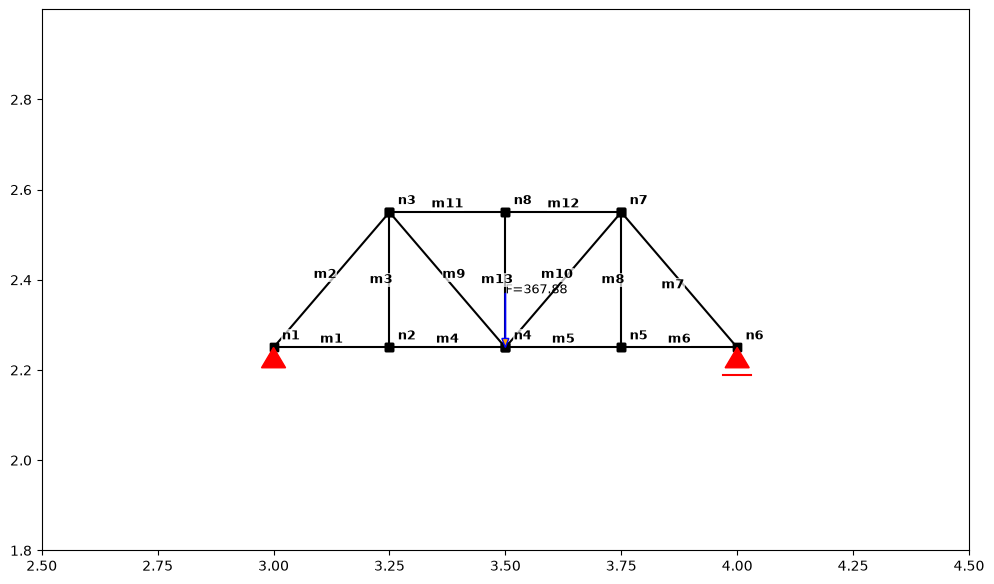

ponte_3.ftl


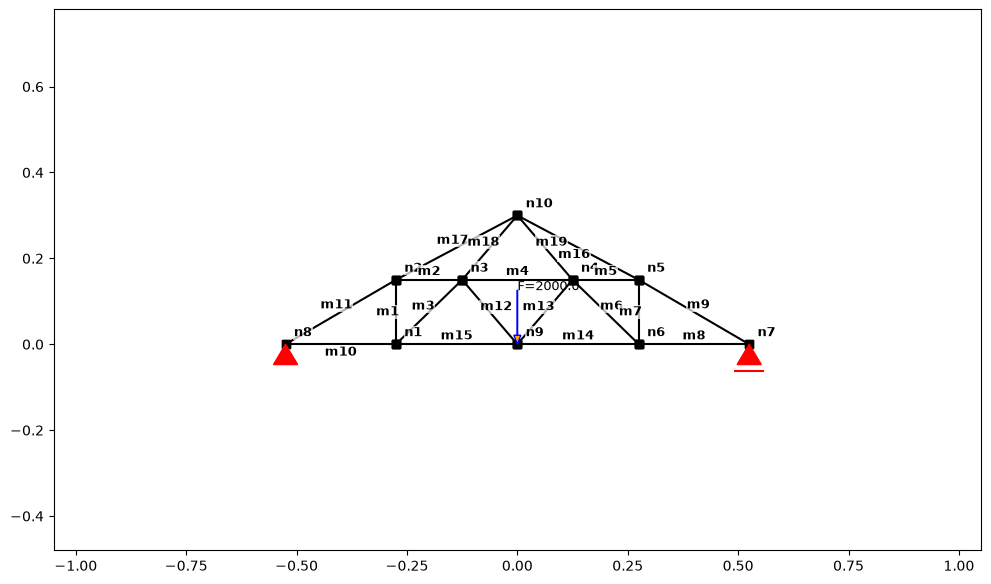

In [9]:
for name, model in models.items():
    print(name)
    _, figure = plot_ftool_model(model, verbosity=0)
    labels = {text.get_text() for text in figure.axes[0].texts}
    assert {f"n{i}" for i in range(1, len(model.nodes) + 1)}.issubset(labels)
    assert {f"m{i}" for i in range(1, len(model.members) + 1)}.issubset(labels)
    load_arrows = [patch for patch in figure.axes[0].patches if hasattr(patch, "_dy")]
    assert load_arrows and all(arrow._dy < 0 for arrow in load_arrows)

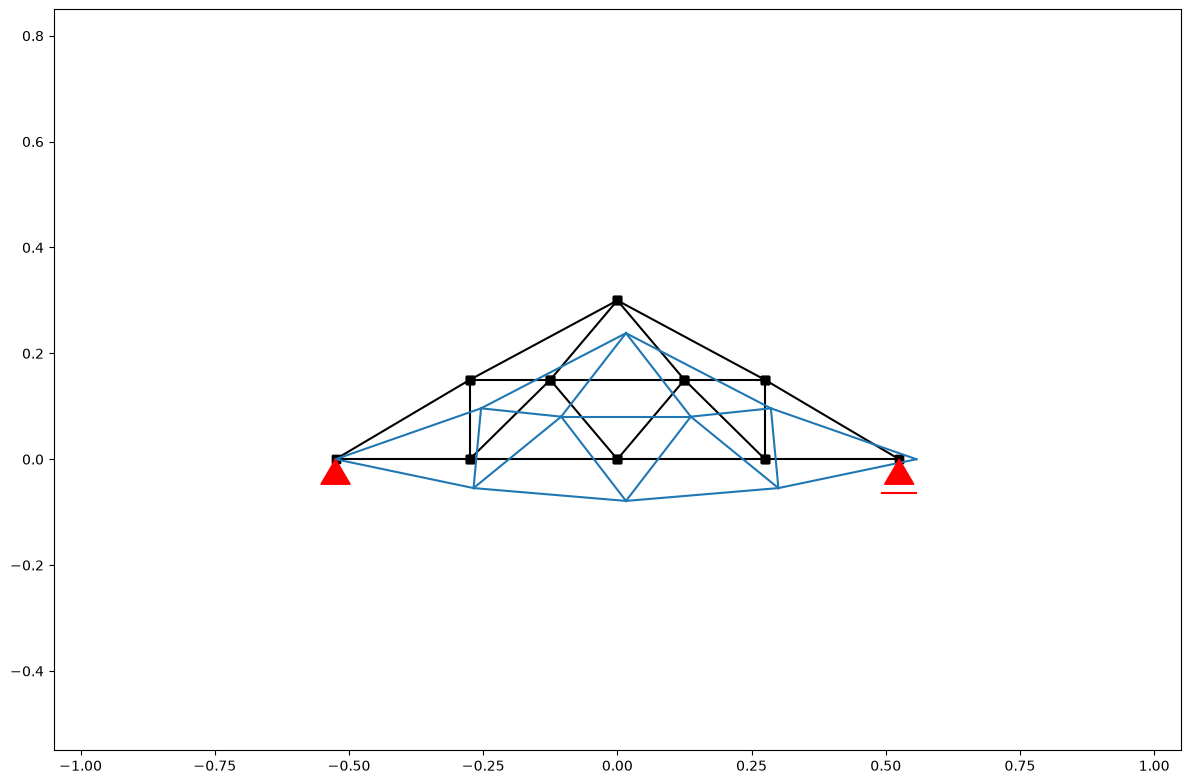

In [10]:
analysis = analyses["ponte_3.ftl"]

plot_anastruct_result(analysis, "displacement", verbosity=0)

## Comparação com o FTool: forças axiais por membro

A vista abaixo usa `N`, mostra os sinais e omite nós, apoios e cargas para permitir a comparação direta barra por barra.

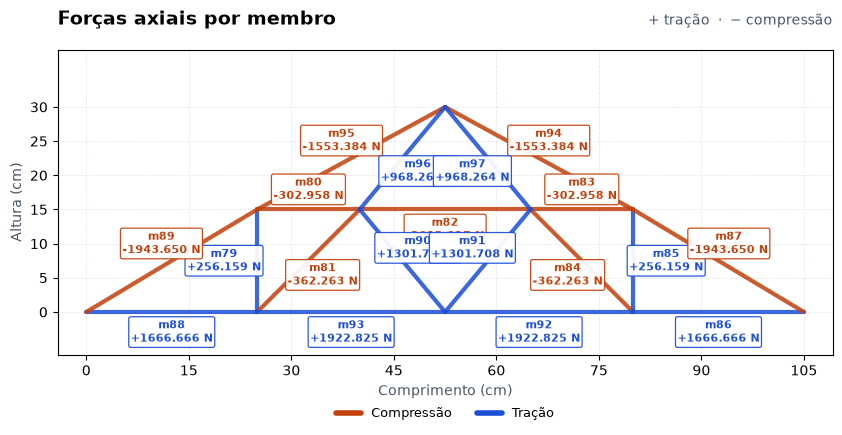

In [11]:
axial_figure = plot_axial_forces(
    models["ponte_3.ftl"],
    analyses["ponte_3.ftl"],
    show=False,
    force_unit="N",
    length_unit="cm",
    decimals=3,
)
axial_axis = axial_figure.axes[0]
axial_labels = [
    text.get_text()
    for text in axial_axis.texts
    if text.get_text().startswith("m")
]
assert len(axial_axis.lines) == len(models["ponte_3.ftl"].members)
assert len(axial_labels) == len(models["ponte_3.ftl"].members)
assert all("N" in label for label in axial_labels)
assert len(axial_axis.patches) == 0
_ = axial_figure